In [1]:
import numpy as np
from scipy.sparse import spdiags, eye, kron
from scipy.sparse.linalg import spsolve, cg
import matplotlib.pyplot as plt

In [4]:
def Amult(U, m):
    h = 1.0 / (m + 1)
    AU = np.zeros_like(U)

    for j in range(m):
        for i in range(m):
            k = i + j*m   # 2D -> 1D index
            
            center = 4 * U[k]
            
            left  = U[k-1]   if i > 0     else 0.0
            right = U[k+1]   if i < m-1   else 0.0
            down  = U[k-m]   if j > 0     else 0.0
            up    = U[k+m]   if j < m-1   else 0.0
            
            AU[k] = (center - left - right - down - up) / h**2

    return AU # this is actually -AU as required for cg


def u_func(x,y):
    return np.sin(4*np.pi*(x+y)) + np.cos(4*np.pi*x*y)

def f_func(x,y):
    term1 = -32*np.pi**2*np.sin(4*np.pi*(x+y))
    term2 = -16*np.pi**2*(x**2 + y**2)*np.cos(4*np.pi*x*y)
    return term1 + term2

def form_rhs(m, f_func, u_func):
    '''
        Form the discretized RHS of a Poisson problem in 2D with rectangular domain
        
        # INPUTS
            m: number of INTERIOR points in the discretized domain
            f_func: RHS as a analytical function of (x,y) of the BVP
            u_func: DC boundary as analytical function of (x,y)

        # OUTPUT
            b: discretized RHS of the interior points in the discretized domain
    '''

    h = 1.0/(m+1)
    b = np.zeros(m**2)

    for j in range(m):
        for i in range(m):

            k = j*m + i
            x = (i+1)*h
            y = (j+1)*h

            b[k] = f_func(x,y)

            # left boundary
            if i == 0:
                b[k] -= u_func(0,y)/h**2

            # right boundary
            if i == m-1:
                b[k] -= u_func(1,y)/h**2

            # bottom boundary
            if j == 0:
                b[k] -= u_func(x,0)/h**2

            # top boundary
            if j == m-1:
                b[k] -= u_func(x,1)/h**2

    return b

U = np.array([1,2,3,4])
m = 2
Amult(U,m)

array([-9, 27, 63, 99])

In [5]:
form_rhs(5, f_func, u_func)

array([ 130.91676514,  -21.62432015, -331.4469546 ,  193.38858143,
          1.80435968,  -21.62432015, -279.60814951,  302.02669086,
         82.43906156, -104.80094657, -331.4469546 ,  302.02669086,
         78.95683521, -218.68336481,  162.94415601,  193.38858143,
         82.43906156, -218.68336481,  165.9865984 , -150.94703893,
          1.80435968, -104.80094657,  162.94415601, -150.94703893,
         -7.14832447])

In [6]:
from scipy.sparse.linalg import cg, LinearOperator
m = 30
F = form_rhs(m,f_func,u_func)

A = LinearOperator( 
    shape=(m**2, m**2),
    matvec=lambda U: Amult(U, m),
    dtype=float
)

residuals = []

def callback(xk):
    r = F + A @ xk
    residuals.append(np.linalg.norm(r))

u, info = cg(A, -F, rtol=1e-12, callback=callback)

print("info =", info)   # info=0 means successful convergence

info = 0


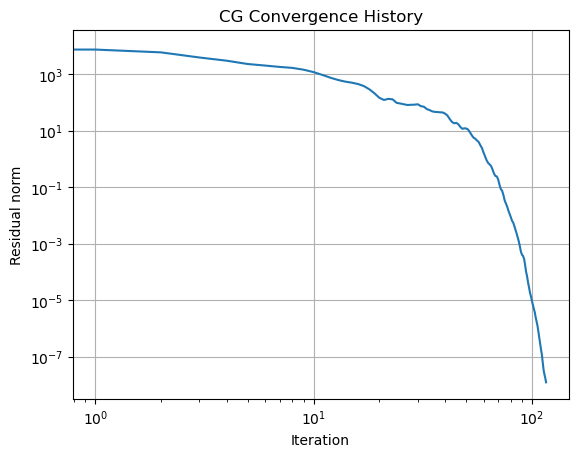

In [7]:
plt.loglog(residuals)
plt.xlabel("Iteration")
plt.ylabel("Residual norm")
plt.title("CG Convergence History")
plt.grid(True)
plt.show()

In [17]:
def exact_solution(m, u_func):
    h = 1/(m+1)
    Ue = np.zeros(m*m)

    for j in range(m):
        for i in range(m):
            x = (i+1)*h
            y = (j+1)*h
            Ue[i +j*m] = u_func(x, y)

    return Ue

done with first half


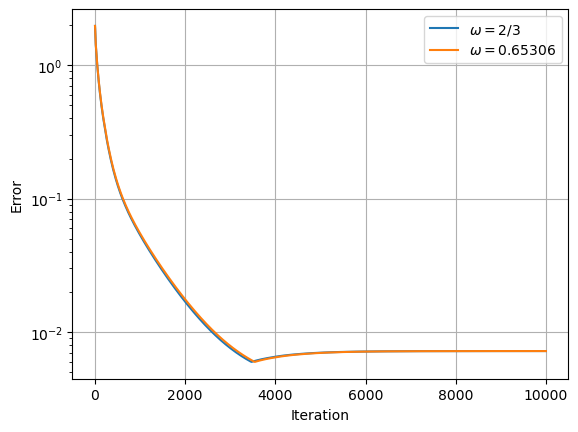

In [22]:
from finite_diff_functions import smooth
m = 50
omega = 2/3
iters = 1 * 10**4

F = form_rhs(m, f_func, u_func)
U = np.zeros(np.size(F))

h = 1/(m+1)
U_exact = exact_solution(m, u_func)

# print(F)
errors = []

for k in range(iters):
    U = smooth(U, omega, m, F)

    err = np.linalg.norm(U - U_exact, np.inf)  # infinity norm
    #err = h*np.linalg.norm(U - U_exact, 2)  # L2-norm
    errors.append(err)

omega = 0.65306
errors2 = []
U = np.zeros(np.size(F))
print("done with first half")

for k in range(iters):
    U = smooth(U, omega, m, F)
    
    err = np.linalg.norm(U - U_exact, np.inf)  # infinity norm
    #err = h*np.linalg.norm(U - U_exact, 2)  # L2-norm
    errors2.append(err)

plt.semilogy(errors, label=rf"$\omega = 2/3$")
plt.semilogy(errors2, label=rf"$\omega = {omega}$")
plt.semilogy()
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.grid(True)
plt.legend()
plt.show()

In [12]:
def exact_solution(m, u_func):
    h = 1/(m+1)
    Ue = np.zeros(m*m)

    for j in range(m):
        for i in range(m):
            x = (i+1)*h
            y = (j+1)*h
            Ue[i +j*m] = u_func(x, y)

    return Ue

In [13]:
def coarsen(R, m):

    mc = m//2
    Rc = np.zeros(mc*mc)

    for jc in range(mc):
        for ic in range(mc):

            i = 2*ic + 1
            j = 2*jc + 1

            k  = i + j*m
            kc = ic + jc*mc

            Rc[kc] = (
                4*R[k]
                + R[k-1] + R[k+1]
                + R[k-m] + R[k+m]
            ) / 8

    return Rc


def interpolate(Rc,m):
    
    
    return R




In [14]:
m = 4
R = np.arange(m**2)
coarsen(R,m) 

IndexError: index 17 is out of bounds for axis 0 with size 16